In [1]:
############################################
# Name: Discovering Patterns in Public Health Data
# Author: Adrian G. Zucco
# Email: adrigabzu@sund.ku.dk
############################################

# Discovering Patterns in Public Health Data

Welcome to this hands-on workshop on **pattern recognition in public health data**. 
You will work with three synthetic (artificially generated) datasets
composed by individuals, their families, and the locations where they live.
The goal is to discover hidden structure in these data using a combination of:

1. **Exploratory Data Analysis (EDA)** -- looking at distributions and
   relationships between variables.
2. **Unsupervised learning** -- grouping similar individuals together *without*
   any predefined labels (clustering).
3. **Supervised learning** -- training a model to *predict* an outcome (sleep
   problems) from the other variables.
4. **Model explainability** -- understanding *how* a complex model makes the
   predictions it does.

No prior Python experience is assumed. Each code cell can be run one at a time;
explanations before and after every cell describe what is happening and why.

## 1. Setup: install and load packages

The cell below installs any missing packages. You only need to run it **once**
(or whenever you work on a new machine). If everything is already installed the
cell does nothing.

In [ ]:
# ---- Install missing packages if not already present in the environment (run once) ----
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "umap": "umap-learn",
    "shap": "shap",
    "skimpy": "skimpy",
    "lightgbm": "lightgbm",
}

for import_name, pip_name in required_packages.items():
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

### Loading packages

Once installed, we **import** every package into our Python session.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import umap
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.decomposition import PCA
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimpy import skim

/home/adrigabzu/anaconda3/envs/mlenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-21 14:00:46.402914: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 14:00:46.578508: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 14:00:48.781695: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You ma

### Setting the project root

A very common error when starting with Python is
*"FileNotFoundError: No such file or directory: '../data/individuals.csv'"*.
This happens when your **working directory** is not where Python expects it.

We use `pathlib` to build paths relative to the location of *this script*,
which always works regardless of where you launched Python or Jupyter from.

In [4]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # In Colab, load data directly from the GitHub repository
    DATA_DIR = "https://raw.githubusercontent.com/adrigabzu/patterns_complexity_public_health_workshop/main/data"
    RESULTS_DIR = "results"
    import os
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print(f"Running in Google Colab. Data directory: {DATA_DIR}")
else:
    # Project root is one level up from the scripts/ folder
    PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
    DATA_DIR = PROJECT_ROOT / "data"
    RESULTS_DIR = PROJECT_ROOT / "results"
    print(f"Project root : {PROJECT_ROOT}")
    print(f"Data directory: {DATA_DIR}")

Project root : /mnt/c/Users/rxk865/OneDrive - University of Copenhagen/Teaching/Complexity PhD course/patterns_complexity_public_health_workshop
Data directory: /mnt/c/Users/rxk865/OneDrive - University of Copenhagen/Teaching/Complexity PhD course/patterns_complexity_public_health_workshop/data


## 2. Data loading and merging

We have three CSV files in the `data/` folder:

| File               | What it contains |
|--------------------|------------------|
| `individuals.csv`  | One row per person: age, sex, occupation, lifestyle and health variables |
| `locations.csv`    | One row per location: population density, average income and wealth |
| `families.csv`     | Links each person to a family and that family's income |

In [5]:
df_ind = pd.read_csv(f"{DATA_DIR}/individuals.csv")
df_loc = pd.read_csv(f"{DATA_DIR}/locations.csv")
df_fam = pd.read_csv(f"{DATA_DIR}/families.csv")

We merge (join) these three tables into a single DataFrame so that every row
contains *all* information about one individual: their personal attributes, the
characteristics of the location they live in, and their family income.

A **left join** keeps every row from the left table and attaches matching
columns from the right table. If a person's location or family ID does not
appear in the lookup table the cells will be filled with `NaN`.

In [6]:
df = df_ind.merge(df_loc, on="Location", how="left")
df = df.merge(
    df_fam[["Person ID", "Family Income", "Family ID"]],
    on="Person ID",
    how="left",
)

Let us take a first look at the merged data. `skim()` gives a rich summary
with counts of missing values, means, histograms, etc.

> **Question for reflection:** How many rows and columns does the merged
> dataset have? Are there any missing values?

In [7]:
print(f"Shape: {df.shape}")
print(df.head())
skim(df)

Shape: (1000, 16)
   Person ID Sex  Age           Occupation Location  Physical Activity Level  \
0          1   M   42  construction worker   loc003                      7.0   
1          2   F   24                nurse   loc001                     10.0   
2          3   M   68               banker   loc010                      3.1   
3          4   M   24        office worker   loc002                     10.0   
4          5   M   76        office worker   loc008                      2.4   

   Stress Levels   BMI  Depressive symptoms  Sleep duration  Sleep problems  \
0              8  20.6                    0             8.0               0   
1              5  24.5                    0             7.3               0   
2              4  27.2                    0            10.0               0   
3              5  25.3                    0             4.5               0   
4              3  32.9                    0             7.1               1   

   Population Density  Ave

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1000   │ │ float64     │ 7     │                                                          │
│ │ Number of columns │ 16     │ │ int64       │ 5     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 4     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean   ┃ sd      ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │       Person ID        │   0 │     0 │  500.5 │   288.8 │      1 │ 250.8 │ 500.5 │ 750.2 │   1000 │ ██████ │  │
│ │          Age           │   0 │     0 │  49.84 │   20.77 │     15 │    31 │    50 │    68 │     85 │ █▇▆▇█▇ │  │
│ │   Physical Activity    │   0 │     0 │  5.849 │   2.789 │      1 │   3.5 │   6.1 │   8.3 │     10 │ ▅▅▅▅▆█ │  │
│ │         Level          │     │       │        │         │        │       │       │       │        │        │  │
│ │     Stress Levels      │   0 │     0 │  5.741 │   2.086 │      1 │     4 │     6 │     7 │     10 │ ▂▂█▅█▃ │  │
│ │          BMI           │   0 │     0 │  24.88 │   3.997 │     15 │  22.3 │    25 │  27.6 │   36.6 │ ▂▄█▇▃  │  │
│ │  Depressive symptoms   │   0 │     0 │  0.033 │  0.1787 │      0 │     0 │     0 │     0 │      1 │   █    │  │
│ │     Sleep duration     │   0 │     0 │  7.043 │   1.524 │    1.5 │     6 │     7 │   8.1 │     10 │  ▁▄█▇▄ │  │
│ │     Sleep problems     │   0 │     0 │   0.35 │  0.4772 │      0 │     0 │     0 │     1 │      1 │ █    ▄ │  │
│ │   Population Density   │   0 │     0 │   2379 │    3192 │  131.5 │ 149.7 │ 856.7 │  1683 │   9764 │ █  ▁ ▁ │  │
│ │     Average Income     │   0 │     0 │  65760 │   28960 │  21250 │ 25690 │ 65050 │ 84520 │ 108200 │ █ ▆▆▄▇ │  │
│ │     Average wealth     │   0 │     0 │  51000 │   12140 │  29070 │ 45290 │ 50750 │ 58790 │  71910 │ ▄▄█▇▆▆ │  │
│ │     Family Income      │   0 │     0 │  59590 │   19140 │  20000 │ 47740 │ 61120 │ 71530 │ 110900 │ ▃▆██▃▁ │  │
│ └────────────────────────┴─────┴───────┴────────┴─────────┴────────┴───────┴───────┴───────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃            ┃    ┃      ┃          ┃            ┃          ┃         ┃ chars per  ┃ words per  ┃ total      ┃  │
│ ┃ column     ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min      ┃ max     ┃ row        ┃ row        ┃ words      ┃  │
│ ┡━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │    Sex     │  0 │    0 │    M     │     M      │    F     │    M    │          1 │          1 │       1000 │  │
│ │ Occupation │  0 │    0 │  nurse   │ constructi │ academic │ student │       10.1 │        1.4 │       1396 │  │
│ │            │    │      │          │ on worker  │    

## 3. Exploratory Data Analysis (EDA)

Before building any model it is crucial to *look* at the data. We use **pair
plots** to visualise distributions (on the diagonal) and bivariate
relationships (off the diagonal) for each dataset.

### Pair plots

> **What to look for:**
>
> - Are some variables clearly correlated (e.g. a rising cloud of points)?
> - Do any distributions look skewed or have unusual peaks?
> - Do categorical variables (like *Sex* or *Occupation*) show different
>   patterns for different groups?

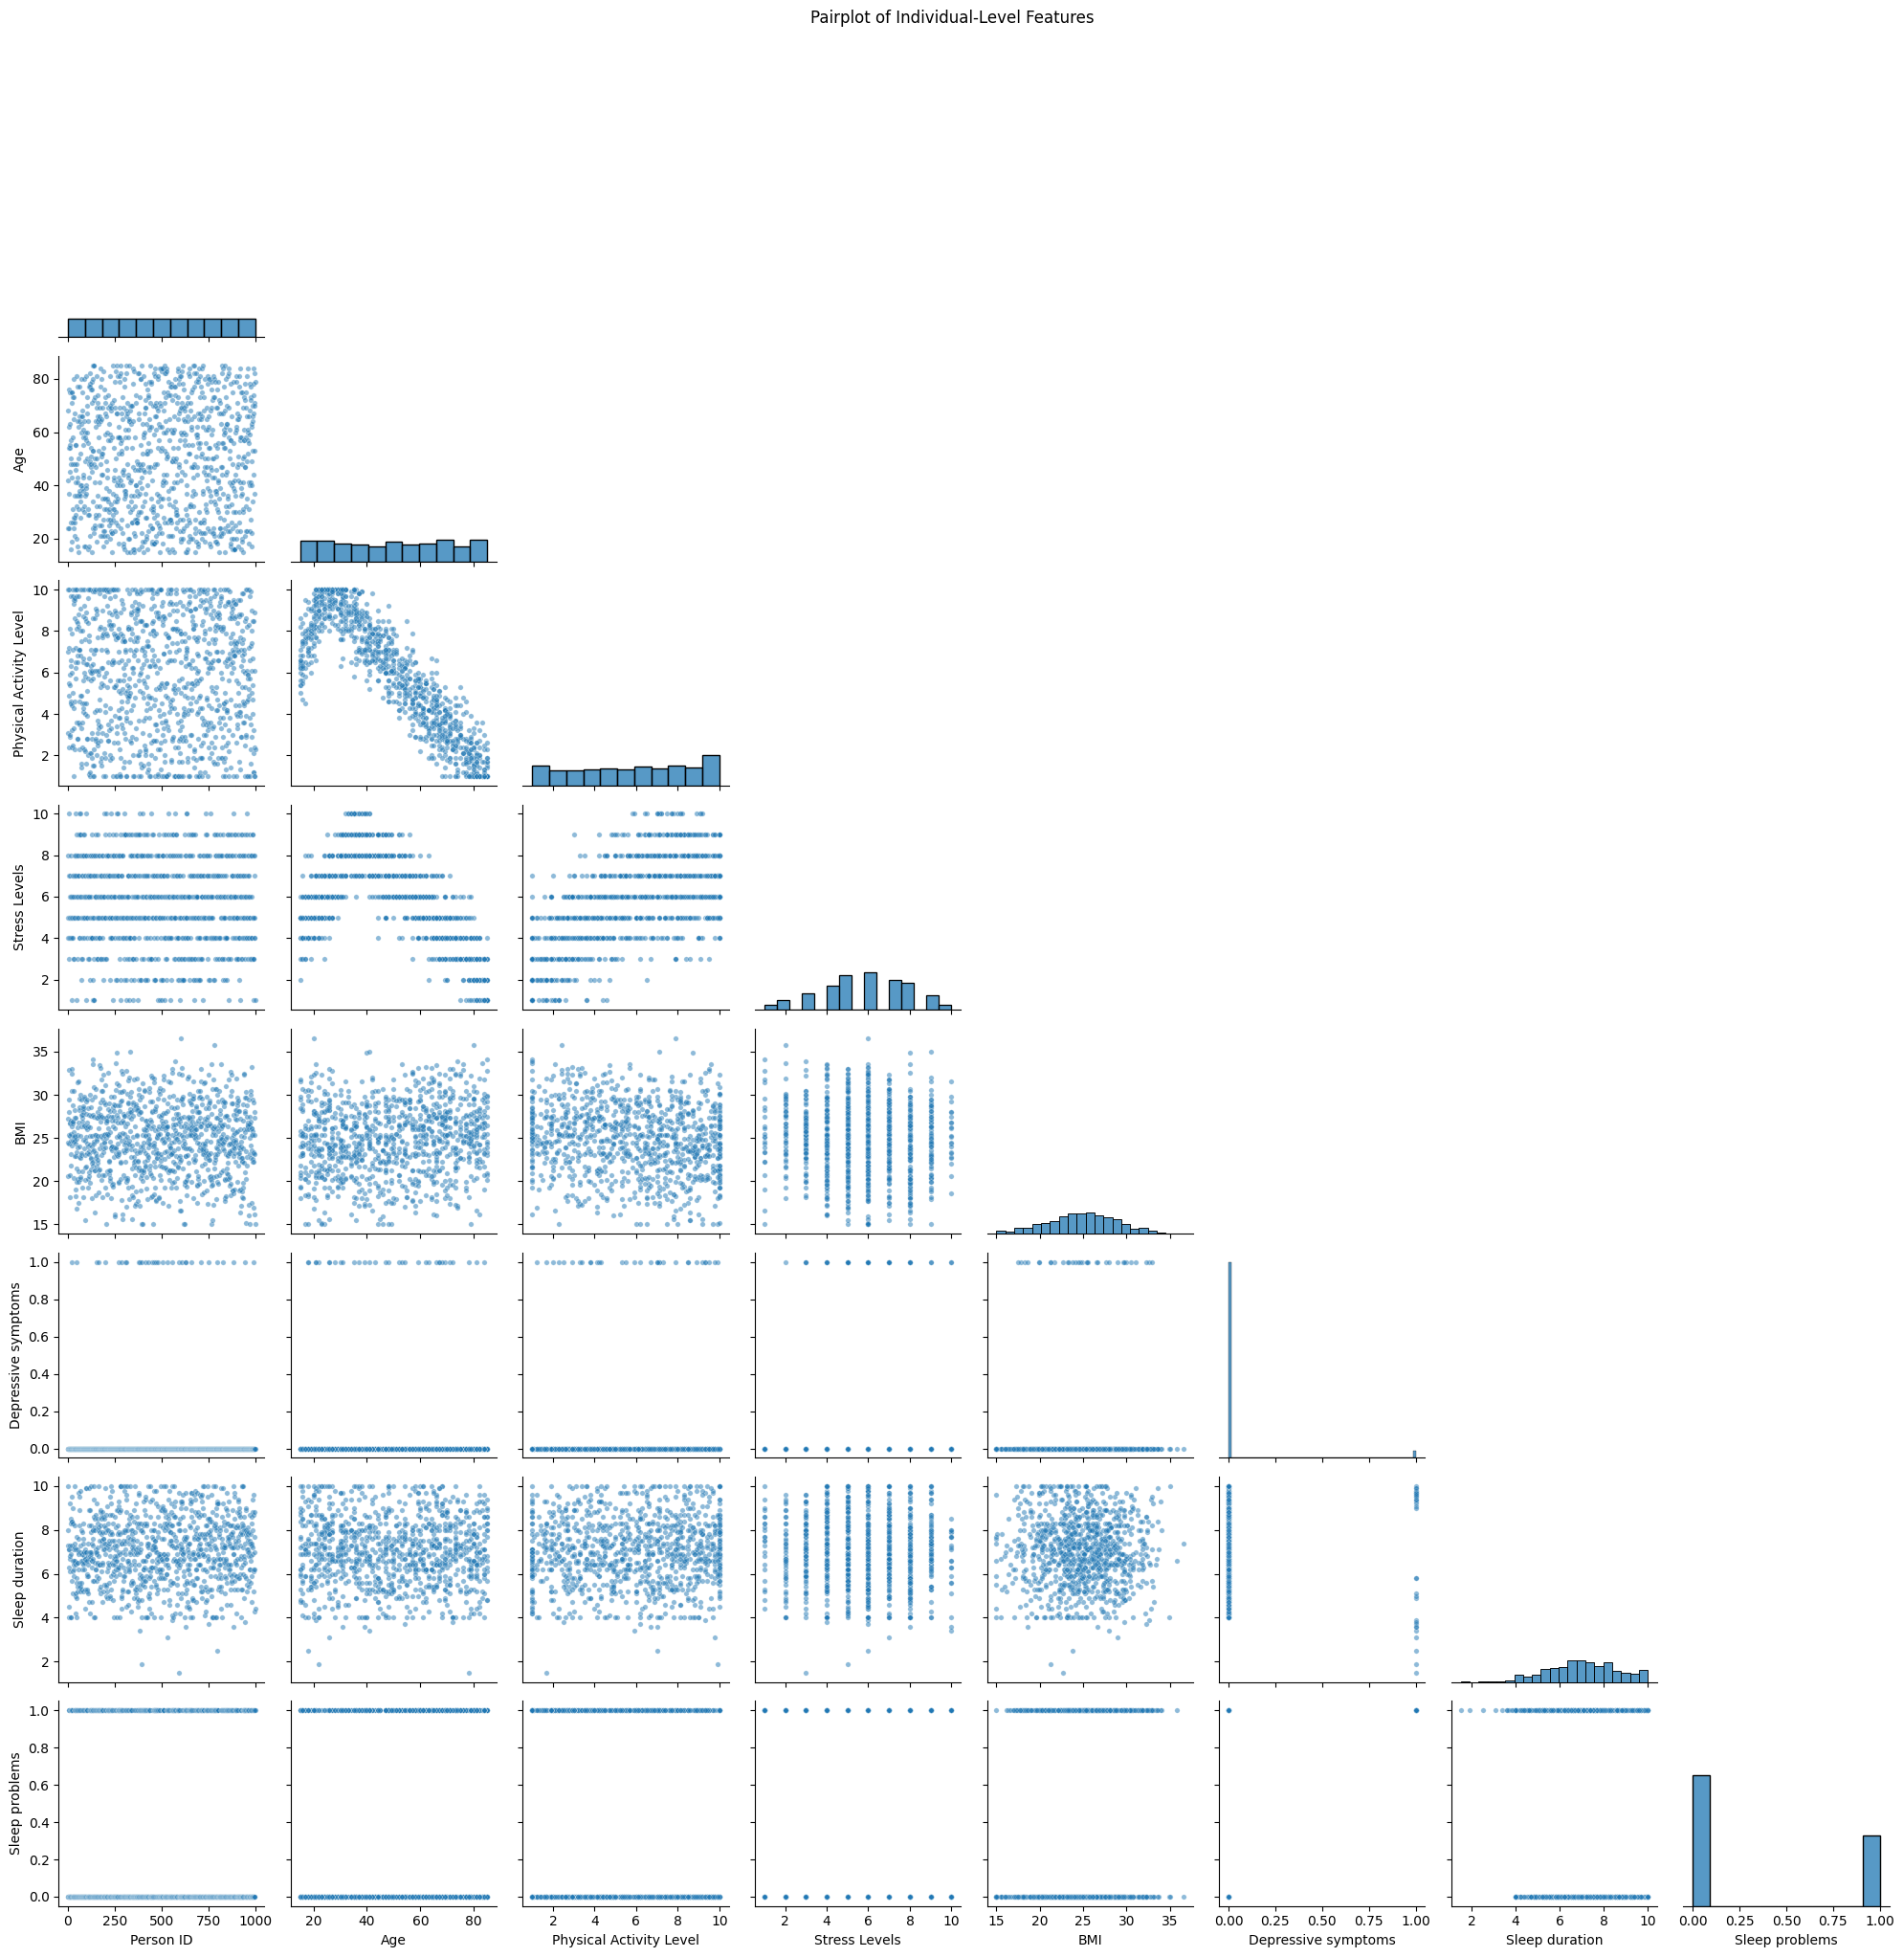

In [8]:
sns.pairplot(df_ind, corner=True, plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pairplot of Individual-Level Features", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

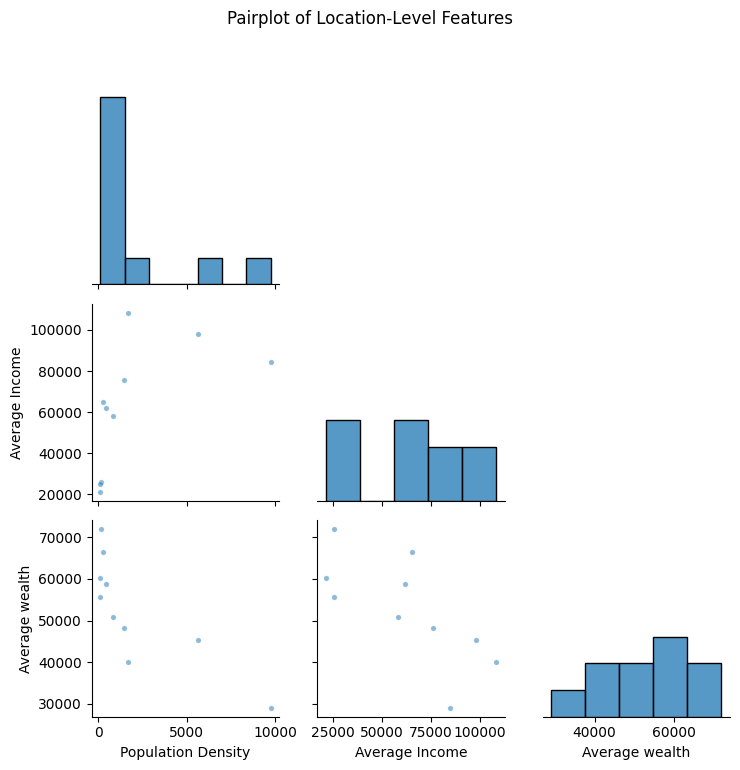

In [9]:
sns.pairplot(df_loc, corner=True, plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pairplot of Location-Level Features", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Unique values in categorical columns

In [10]:
for col in ["Occupation", "Sex", "Location"]:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}\n")

Occupation: <ArrowStringArray>
['construction worker',               'nurse',              'banker',
       'office worker',            'academic',             'student']
Length: 6, dtype: str

Sex: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str

Location: <ArrowStringArray>
['loc003', 'loc001', 'loc010', 'loc002', 'loc008', 'loc006', 'loc009',
 'loc004', 'loc005', 'loc007']
Length: 10, dtype: str



## 4. Data preprocessing: encoding

Analyses using computational models require us to map our data and concepts into numbers
in a way that we can represent meaningful differences between observations.
We therefore need to convert categorical variables (like *Sex* or *Occupation*) into numeric
columns. A common approach is **one-hot encoding**: each category becomes its
own 0/1 column. This is sometimes done under the hood when using statistical models, 
but here we do it explicitly so we can make sure that different categories
are numerically differentiated.

In [11]:
# Drop identifier columns and the raw Location name (its features are already merged in)
to_drop = ["Person ID", "Family ID", "Location"]
data_noids = df.drop(columns=to_drop, errors="ignore")

# One-hot encode Occupation and Sex
# drop_first=True automatically drops one level per variable to avoid multicollinearity
data_encoded = pd.get_dummies(data_noids, columns=["Occupation", "Sex"], drop_first=True)

# Convert any boolean columns produced by get_dummies to integers (0/1)
bool_cols = data_encoded.select_dtypes(include=["bool"]).columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

print(f"Encoded shape: {data_encoded.shape}")
skim(data_encoded)

Encoded shape: (1000, 17)


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1000   │ │ int64       │ 10    │                                                          │
│ │ Number of columns │ 17     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean   ┃ sd      ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │          Age           │   0 │     0 │  49.84 │   20.77 │     15 │    31 │    50 │    68 │     85 │ █▇▆▇█▇ │  │
│ │   Physical Activity    │   0 │     0 │  5.849 │   2.789 │      1 │   3.5 │   6.1 │   8.3 │     10 │ ▅▅▅▅▆█ │  │
│ │         Level          │     │       │        │         │        │       │       │       │        │        │  │
│ │     Stress Levels      │   0 │     0 │  5.741 │   2.086 │      1 │     4 │     6 │     7 │     10 │ ▂▂█▅█▃ │  │
│ │          BMI           │   0 │     0 │  24.88 │   3.997 │     15 │  22.3 │    25 │  27.6 │   36.6 │ ▂▄█▇▃  │  │
│ │  Depressive symptoms   │   0 │     0 │  0.033 │  0.1787 │      0 │     0 │     0 │     0 │      1 │   █    │  │
│ │     Sleep duration     │   0 │     0 │  7.043 │   1.524 │    1.5 │     6 │     7 │   8.1 │     10 │  ▁▄█▇▄ │  │
│ │     Sleep problems     │   0 │     0 │   0.35 │  0.4772 │      0 │     0 │     0 │     1 │      1 │ █    ▄ │  │
│ │   Population Density   │   0 │     0 │   2379 │    3192 │  131.5 │ 149.7 │ 856.7 │  1683 │   9764 │ █  ▁ ▁ │  │
│ │     Average Income     │   0 │     0 │  65760 │   28960 │  21250 │ 25690 │ 65050 │ 84520 │ 108200 │ █ ▆▆▄▇ │  │
│ │     Average wealth     │   0 │     0 │  51000 │   12140 │  29070 │ 45290 │ 50750 │ 58790 │  71910 │ ▄▄█▇▆▆ │  │
│ │     Family Income      │   0 │     0 │  59590 │   19140 │  20000 │ 47740 │ 61120 │ 71530 │ 110900 │ ▃▆██▃▁ │  │
│ │   Occupation_banker    │   0 │     0 │  0.177 │  0.3819 │      0 │     0 │     0 │     0 │      1 │ █    ▂ │  │
│ │ Occupation_constructio │   0 │     0 │  0.185 │  0.3885 │      0 │     0 │     0 │     0 │      1 │ █    ▂ │  │
│ │        n worker        │     │       │        │         │        │       │       │       │        │        │  │
│ │    Occupation_nurse    │   0 │     0 │  0.191 │  0.3933 │      0 │     0 │     0 │     0 │      1 │ █    ▂ │  │
│ │   Occupation_office    │   0 │     0 │  0.211 │  0.4082 │      0 │     0 │     0 │     0 │      1 │ █    ▂ │  │
│ │         worker         │     │       │        │         │        │       │       │       │        │        │  │
│ │   Occupation_student   │   0 │     0 │   0.05 │  0.2181 │      0 │     0 │     0 │     0 │      1 │   █    │  │
│ │         Sex_M          │   0 │     0 │  0.502 │  0.5002 │      0 │     0 │     1 │     1 │      1 │ █    █ │  │
│ └────────────────────────┴─────┴───────┴────────┴─────────┴────────┴───────┴───────┴───────┴────────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

> **What is multicollinearity?**
> If we keep *both* `Sex_F` and `Sex_M` columns, one is a perfect linear
> function of the other (`Sex_M = 1 - Sex_F`). Some algorithms struggle with
> such redundancy, so we drop one.

## 5. Visualising the encoded data

### Feature heatmap

A heatmap lets us see all **1000 individuals x features** at a glance. We
*scale* every column to zero mean and unit variance first so that features
with different units (e.g. age in years vs. BMI) are visually comparable.

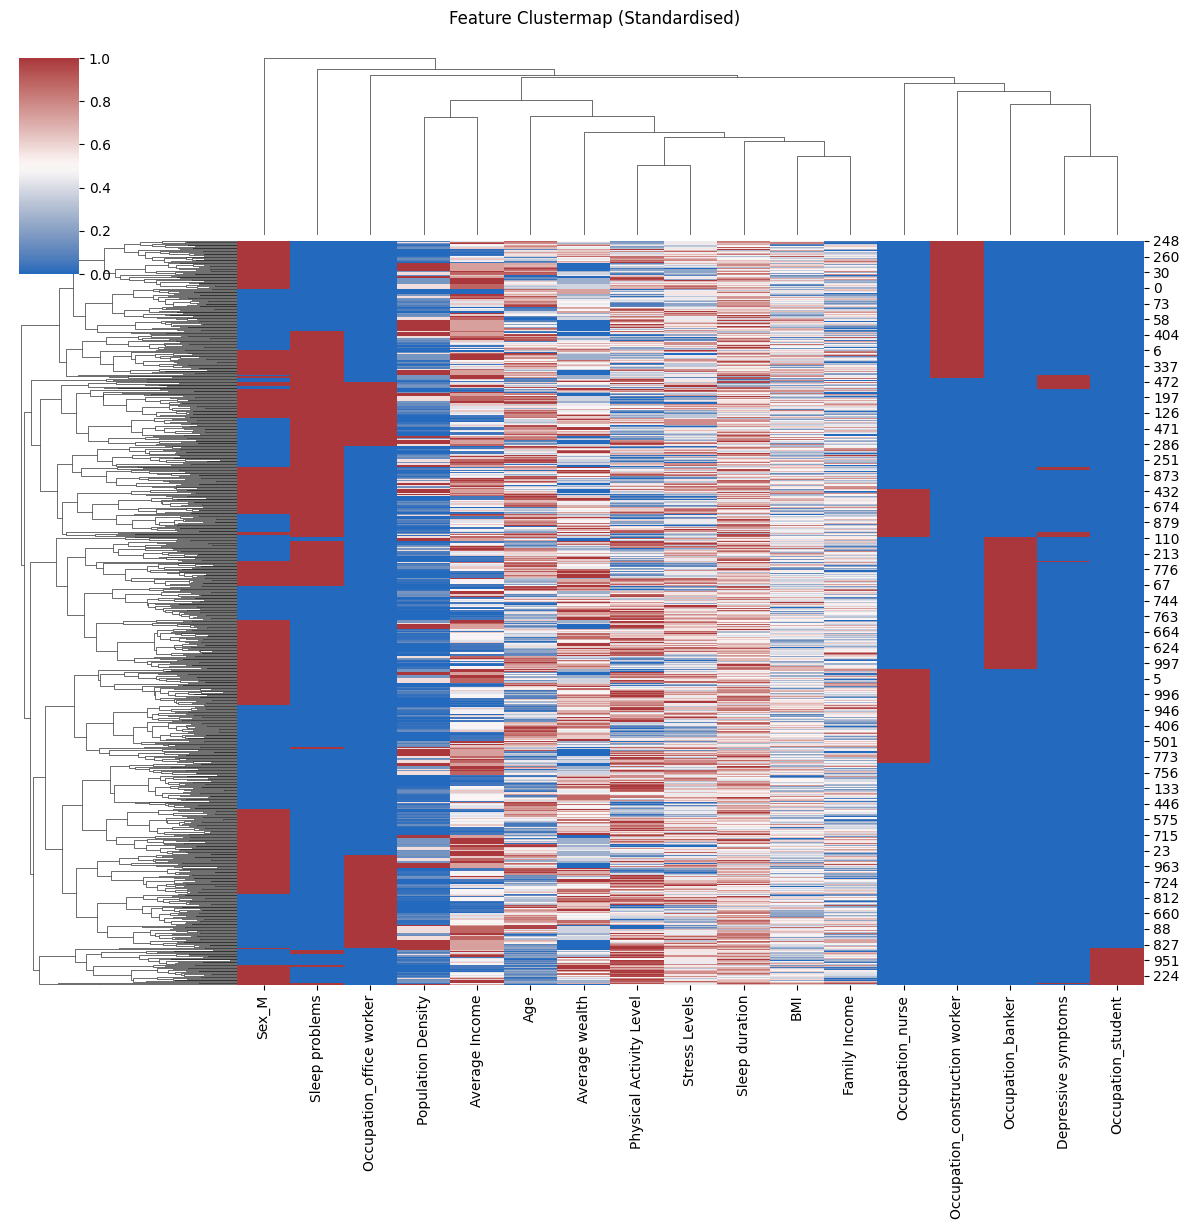

In [12]:
sns.clustermap(data_encoded, standard_scale=1, cmap="vlag", figsize=(12, 12))
plt.suptitle("Feature Clustermap (Standardised)", y=1.02)
plt.show()

### Correlation plot

Next we look at **Spearman correlations** between features. This metric is 
robust to non-linear relationships and outliers.

> **What to look for:** Clusters of strongly correlated features may represent
> related concepts our potential *interactions*. However, such correlations
> can be overinterpreted, they do not necessarily imply a causal relationship, and may
> be driven by confounding variables or data artifacts.

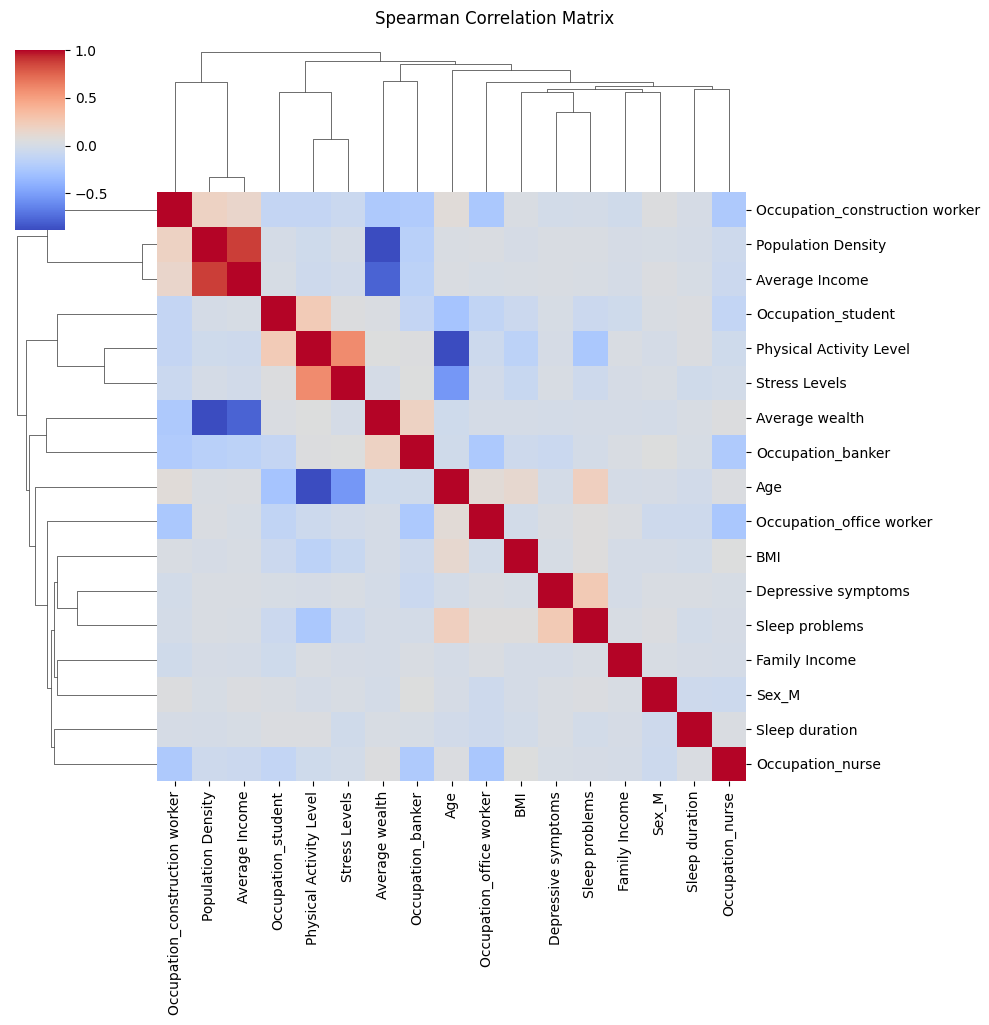

In [13]:
corr_spearman = data_encoded.corr(method="spearman")
sns.clustermap(corr_spearman, cmap="coolwarm", annot=False, figsize=(10, 10))
plt.suptitle("Spearman Correlation Matrix", y=1.02)
plt.show()

## 6. Unsupervised learning: clustering

Clustering tries to find **groupings** in the data without using any
outcome variable. We will try two very different approaches:

| Method       | Key idea |
|--------------|----------|
| **K-means**  | Partition the data into exactly *k* spherical clusters of similar size |
| **HDBSCAN**  | Find clusters of *varying* shape and density; can label points as "noise" |

In [14]:
# Standardise all features -- critical so that variables measured in large
# units (e.g. income) don't dominate the distance calculations.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

### K-means clustering

K-means needs us to choose the number of clusters in advance. Here we set
`k = 3` as a starting point. 

> Assessing how many clusters to choose is one of the biggest challenges in unsupervised learning.
> In practice one would try to assess by different methods such as **elbow plot** or
> **silhouette score** to pick *k*.

In [15]:
km_model = KMeans(n_clusters=3, n_init=25, random_state=2025)
km_labels = km_model.fit_predict(X_scaled)

#### Visualising clusters with PCA

Our data has many columns. To *plot* the clusters in 2-D we project them onto
the first two **principal components (PCs)**, the two directions that capture
the most variance.

In [16]:
pca = PCA(random_state=420)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]:.3f}")
print(f"Variance explained by PC2: {explained_variance[1]:.3f}")
print(f"Cumulative (first 10 PCs):  {np.cumsum(explained_variance[:10])}")

Variance explained by PC1: 0.158
Variance explained by PC2: 0.144
Cumulative (first 10 PCs):  [0.15756295 0.30139379 0.37963375 0.45425753 0.52552388 0.59158438
 0.65235245 0.71099392 0.76816238 0.82375006]


Now we overlay the K-means cluster labels and the **loading arrows** (which
show how each original feature contributes to the principal components).

> **How to read this plot:**
> - Each **point** is a person, coloured by their cluster.
> - The **arrows** show which features drive the separation. Longer arrows =
>   more influential features. Arrows pointing in the same direction are
>   positively correlated on these components.

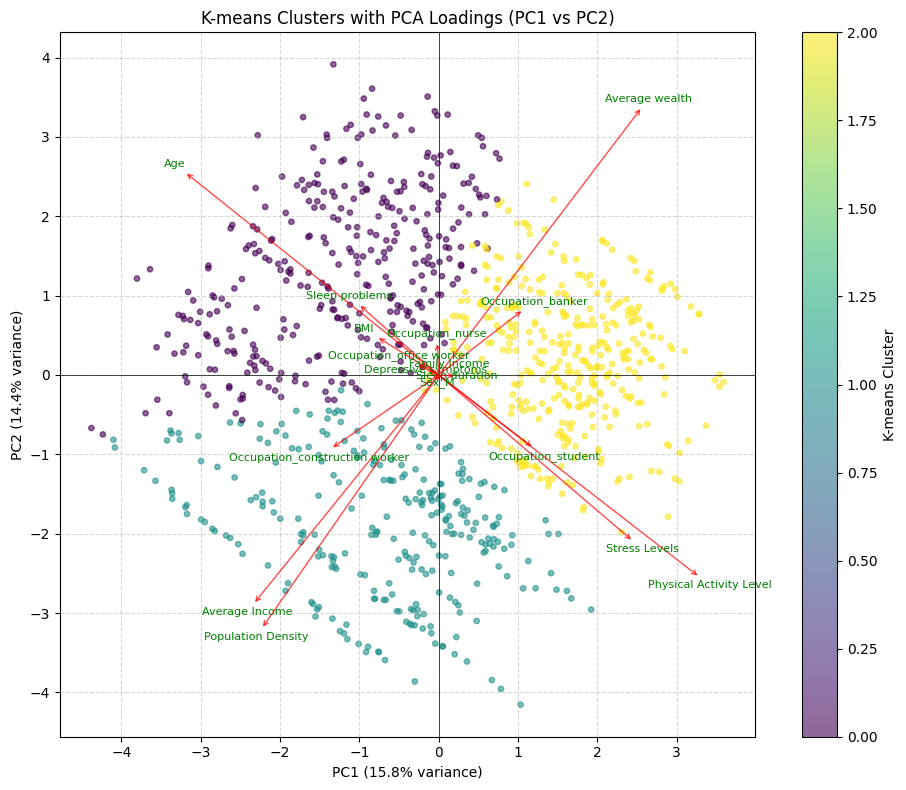

In [17]:
loadings = pca.components_.T[:, :2]  # first two PCs
feature_names = data_encoded.columns

# Scale loading arrows so they are visible on the score plot
plot_diag = np.sqrt(np.ptp(X_pca[:, 0])**2 + np.ptp(X_pca[:, 1])**2)
max_load = np.max(np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2))
scale_f = (plot_diag * 0.35) / max_load if max_load > 1e-6 else 1

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=km_labels, cmap="viridis", s=15, alpha=0.6,
)
plt.colorbar(scatter, ax=ax, label="K-means Cluster")

for i, feat in enumerate(feature_names):
    ax.annotate(
        feat,
        xy=(0, 0),
        xytext=(loadings[i, 0] * scale_f * 1.1, loadings[i, 1] * scale_f * 1.1),
        arrowprops=dict(arrowstyle="<-", color="red", alpha=0.7),
        fontsize=8, color="green", ha="center", va="center",
    )

ax.set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}% variance)")
ax.set_title("K-means Clusters with PCA Loadings (PC1 vs PC2)")
ax.set_aspect("equal")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### HDBSCAN clustering

HDBSCAN does not require us to choose the number of clusters. Instead, it
finds dense regions and labels sparse points as **noise** (cluster -1).

Before running HDBSCAN we reduce dimensionality with **UMAP** (Uniform
Manifold Approximation and Projection), which preserves local neighbourhood
structure better than PCA and works well as input for density-based clustering.

> **Why UMAP before HDBSCAN?**
> Density-based methods like HDBSCAN struggle in high-dimensional spaces — a
> phenomenon known as the **curse of dimensionality**. As the number of
> dimensions grows, distances between points become increasingly uniform,
> making it hard to distinguish "dense" from "sparse" regions. UMAP compresses
> the data into a low-dimensional (2-D) embedding while preserving local
> neighbourhood structure, giving HDBSCAN a cleaner, more meaningful distance
> landscape to work with.

In [18]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=2025)
X_umap = umap_model.fit_transform(X_scaled)

clusterer = HDBSCAN(min_cluster_size=15)
labels_umap = clusterer.fit_predict(X_umap)

n_clusters_found = len(set(labels_umap)) - (1 if -1 in labels_umap else 0)
n_noise = np.sum(labels_umap == -1)
print(f"Clusters found (excl. noise): {n_clusters_found}")
print(f"Noise points (cluster -1):    {n_noise}")

/home/adrigabzu/anaconda3/envs/mlenv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clusters found (excl. noise): 7
Noise points (cluster -1):    0


/home/adrigabzu/anaconda3/envs/mlenv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


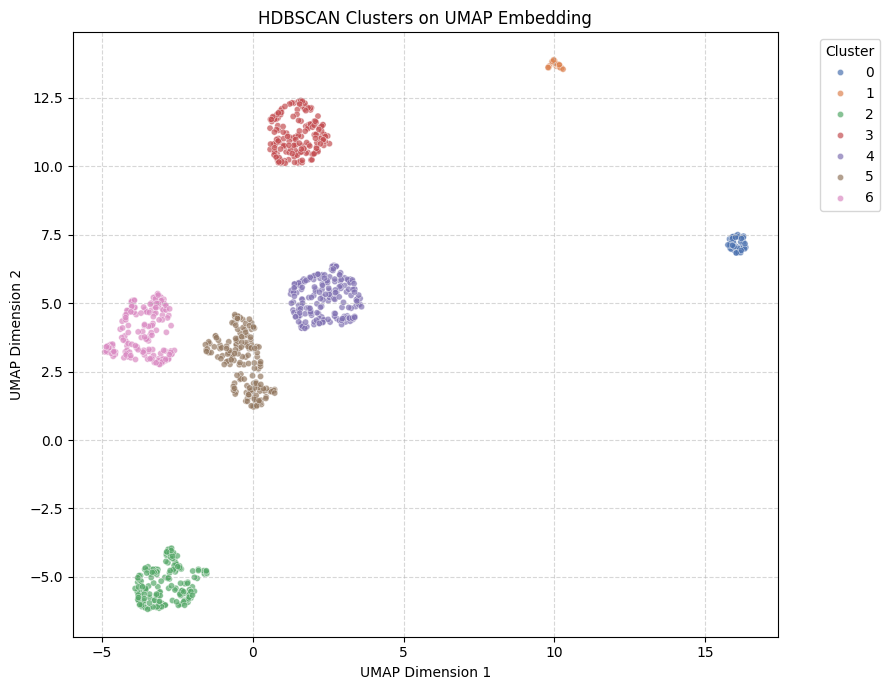

In [19]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=labels_umap,
    palette="deep",
    s=20, alpha=0.7, legend="full",
)
plt.title("HDBSCAN Clusters on UMAP Embedding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

> **K-means vs HDBSCAN:** K-means always assigns every point to a cluster and
> assumes roughly spherical clusters of similar size. HDBSCAN can discover
> irregularly shaped clusters and exposes when a point does not belong
> anywhere (noise). Try changing `min_cluster_size` and see how the results
> change!

### Summary statistics by cluster

To **interpret** the clusters we go back to the original (unencoded) variables
and compute summary statistics within each cluster.

> **Question for reflection:** Do the clusters correspond to recognisable
> subpopulations? For example, do some clusters have higher stress, lower
> physical activity, or more sleep problems?

In [20]:
df_clusters = df.copy()
df_clusters["cluster"] = labels_umap

# Exclude noise points (-1)
valid_clusters_df = df_clusters[df_clusters["cluster"] != -1]

if not valid_clusters_df.empty:
    top_clusters = valid_clusters_df["cluster"].value_counts().nlargest(5).index.tolist()
    print(f"Top 5 clusters by size: {top_clusters}\n")

    for c in top_clusters:
        cluster_data = valid_clusters_df[valid_clusters_df["cluster"] == c]
        print(f"\n--- Cluster {c} (n={len(cluster_data)}) ---")
        print(cluster_data.describe())
else:
    print("No valid clusters found (all points classified as noise).")

Top 5 clusters by size: [4, 6, 3, 5, 2]


--- Cluster 4 (n=202) ---
        Person ID         Age  Physical Activity Level  Stress Levels  \
count  202.000000  202.000000               202.000000     202.000000   
mean   495.128713   53.757426                 5.532673       5.549505   
std    289.905978   19.788825                 2.815968       2.212588   
min      4.000000   15.000000                 1.000000       1.000000   
25%    229.750000   36.000000                 3.125000       4.000000   
50%    488.500000   54.000000                 5.600000       6.000000   
75%    762.250000   70.000000                 7.900000       7.000000   
max    993.000000   85.000000                10.000000      10.000000   

              BMI  Depressive symptoms  Sleep duration  Sleep problems  \
count  202.000000                202.0      202.000000      202.000000   
mean    24.830198                  0.0        6.949010        0.381188   
std      4.133943                  0.0        1.4373

## 7. Supervised learning: predicting sleep problems

So far we have explored the data without a specific labels/outcome. Now we switch to
**supervised learning**: we ask the model to predict whether an individual has
**sleep problems** (0 = no, 1 = yes) from all other features.

### Train/test split

We split the data randomly into a **training set** (80 %) used to fit the model and a
**test set** (20 %) used to evaluate it. Stratifying on the outcome ensures
that the proportion of sleep problems is similar in both sets.

In [21]:
target_column = "Sleep problems"

if target_column not in data_encoded.columns:
    raise ValueError(f"Target column '{target_column}' not found in data_encoded.")

# We remove the target column from the features and keep it as the label vector y
X = data_encoded.drop(columns=[target_column])
y = data_encoded[target_column].astype(int)

print(f"Target distribution:\n{y.value_counts(normalize=True)}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2025, stratify=y,
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Target distribution:
Sleep problems
0    0.65
1    0.35
Name: proportion, dtype: float64

Training set: 800 rows
Test set:     200 rows


### Training a LightGBM model

[LightGBM](https://lightgbm.readthedocs.io/) is a gradient-boosting framework
that builds an ensemble of decision trees sequentially, each one correcting the
errors of the previous one. It is fast, handles missing values natively, and
works well with tabular data.

> **Note on categorical features:** One-hot encoding is a fundamental concept
> worth understanding, but advanced tree-based models like LightGBM can
> natively handle raw categorical (text) columns without any manual encoding.
> In a production workflow you could pass `Occupation` and `Sex` directly and
> set `categorical_feature` in the fit call, letting the model find the optimal
> splits internally.

In [ ]:
clf = LGBMClassifier(
    n_estimators=100, random_state=2025, num_leaves = 7, max_depth = 3
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # probability of class 1

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 280, number of negative: 520
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350000 -> initscore=-0.619039
[LightGBM] [Info] Start training from score -0.619039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

### Evaluating the model

We predict on the held-out test set and compute several **classification
metrics**:

| Metric              | What it tells you |
|---------------------|-------------------|
| **Accuracy**        | Overall fraction of correct predictions |
| **ROC AUC**         | How well the model ranks positive cases above negative ones (1 = perfect) |
| **PR AUC**          | Area under the precision-recall curve (useful with imbalanced classes, aka low number of cases) |
| **Sensitivity** (recall) | Fraction of actual positives correctly identified |
| **Specificity**     | Fraction of actual negatives correctly identified |

> **Question for reflection:** Is accuracy alone a good metric here? What if
> only 10 % of people have sleep problems -- could a model that always predicts
> "no" still reach 90 % accuracy?

In [23]:
baseline_acc = max(y_train.mean(), 1 - y_train.mean())
print(f"Baseline Accuracy (majority class): {baseline_acc:.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR AUC   : {average_precision_score(y_test, y_proba):.3f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, digits=3)}")

Baseline Accuracy (majority class): 0.650
Accuracy : 0.680
ROC AUC  : 0.640
PR AUC   : 0.500

Classification Report:
              precision    recall  f1-score   support

           0      0.720     0.831     0.771       130
           1      0.560     0.400     0.467        70

    accuracy                          0.680       200
   macro avg      0.640     0.615     0.619       200
weighted avg      0.664     0.680     0.665       200



### Confusion matrix

The **confusion matrix** shows the counts of true positives, true negatives,
false positives and false negatives in a 2x2 table.

In [24]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: No sleep problems", "Actual: Sleep problems"],
    columns=["Predicted: No", "Predicted: Yes"],
)
print("Confusion Matrix (rows = actual, columns = predicted):")
print(cm_df.to_string())

Confusion Matrix (rows = actual, columns = predicted):
                           Predicted: No  Predicted: Yes
Actual: No sleep problems            108              22
Actual: Sleep problems                42              28


## 8. A linear baseline: logistic regression

Before diving into SHAP, we train a **logistic regression** as a linear
baseline. Logistic regression is one of the workhorses of epidemiology and
public health: it is fast, transparent, and its coefficients have a direct
probabilistic interpretation (log-odds).

This is also a deliberate nod to **complexity science**: logistic regression
assumes that risk factors combine *additively* and *linearly* on the log-odds
scale. In a truly complex system — where variables interact non-linearly and
effects depend on context — that assumption may not hold. Comparing the linear
model against LightGBM will reveal how much is lost (or gained) by relaxing
the linearity constraint.

We scale the features first so that coefficients are on a comparable scale
(each one represents the change in log-odds per **standard deviation** of
the feature).

In [25]:
scaler_lr = StandardScaler()
X_train_sc = scaler_lr.fit_transform(X_train)
X_test_sc = scaler_lr.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=2025)
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

### Head-to-head performance comparison

The table below puts both models side by side on the same test set.

> **Question for reflection:** How much does the non-linear LightGBM model
> outperform the linear logistic regression? A large gap suggests the data
> contains important **interactions or non-linearities** that a linear model
> cannot capture — a hallmark of complex systems. A small gap suggests the
> relationship is largely additive and linear.

In [26]:
metrics = {
    "Model": ["Logistic Regression", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, y_pred),
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, y_proba),
    ],
    "PR AUC": [
        average_precision_score(y_test, lr_proba),
        average_precision_score(y_test, y_proba),
    ],
}
df_metrics = pd.DataFrame(metrics).set_index("Model")
print(df_metrics.to_string(float_format="{:.3f}".format))

                     Accuracy  ROC AUC  PR AUC
Model                                         
Logistic Regression     0.665    0.707   0.598
LightGBM                0.680    0.640   0.500


## 9. Model explainability: SHAP values

A model that predicts well could be useful but more interesting is to know
what the model learn from the data. Traditional statistical models (like logistic regression)
have coefficients that are based on the mean effect of each feature across the whole dataset.
SHAP (SHapley Additive exPlanations) can help us decompose the contributions of each feature,
and for each individual prediction, based on the idea of Shapley values from cooperative game theory.

- A **positive** SHAP value for a feature means it *pushes the prediction
  towards* sleep problems for that person.
- A **negative** SHAP value means it *pushes the prediction away from* sleep
  problems.

### Computing SHAP values

In [ ]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

### Global feature importance

The **bar plot** shows the mean absolute SHAP value for each feature -- a
measure of that feature's overall importance across all individuals in the
test set.

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP|)")
plt.tight_layout()
plt.show()

### SHAP beeswarm plot

The **beeswarm** plot goes one step further. Each dot is one individual. The
horizontal position shows the SHAP value (how much the feature pushed the
prediction) and the colour shows the feature's *actual value* (red = high,
blue = low).

> **How to read the beeswarm:** If a feature shows red dots on the right and
> blue dots on the left, then *higher values of that feature increase the
> predicted risk of sleep problems*. The reverse pattern means higher values
> are protective.

In [ ]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary (Beeswarm) -- LightGBM")
plt.tight_layout()
plt.show()

### Logistic regression coefficients vs LightGBM SHAP values

Now we can directly compare what the two models have learned about feature
importance.

- **LR coefficients** (standardised) tell us the *average*, *linear*
  log-odds contribution of each feature.
- **Mean |SHAP|** values tell us the *average magnitude* of each feature's
  contribution to the LightGBM predictions.

Features that rank similarly in both views are robustly important regardless
of modelling assumptions. Features that rank very differently hint at
**non-linearities or interactions** that the linear model misses — a key
signature of complex systems.

In [ ]:
# Mean absolute SHAP values per feature (LightGBM)
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns,
    name="Mean |SHAP|",
)

# Logistic regression standardised coefficients (absolute value for magnitude)
lr_coef = pd.Series(
    np.abs(lr.coef_[0]),
    index=X_train.columns,
    name="|LR Coefficient|",
)

# Combine into one DataFrame, sort by SHAP importance
df_compare = pd.concat([mean_abs_shap, lr_coef], axis=1).sort_values(
    "Mean |SHAP|", ascending=False
)

# --- Side-by-side bar chart ---
n_features = len(df_compare)
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, n_features * 0.35)), sharey=True)

for ax, col, color, title in zip(
    axes,
    ["Mean |SHAP|", "|LR Coefficient|"],
    ["darkorange", "steelblue"],
    ["LightGBM — Mean |SHAP value|", "Logistic Regression — |Coefficient| (std. units)"],
):
    ax.barh(df_compare.index, df_compare[col], color=color, alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.suptitle(
    "Feature Importance: LightGBM SHAP vs Logistic Regression Coefficients",
    fontsize=12,
)
plt.tight_layout()
plt.show()

> **What to look for:**
> - Features near the **top of both charts** are important under both linear
>   and non-linear assumptions — these are your most reliable signals.
> - Features that appear only in the **SHAP chart** (high SHAP, low LR
>   coefficient) are likely involved in **interactions or threshold effects**
>   that the logistic model may not represent.
> - Features that appear only in the **LR chart** may have a consistent
>   additive effect that the tree model spreads across correlated features.

### SHAP dependence plots

A dependence plot zooms in on **one feature** and shows exactly how its value
relates to its SHAP contribution. A second feature is used for colour to
reveal **interactions**.

> **Try it yourself:** Replace `"Physical Activity Level"` or
> `"Stress Levels"` with another feature name (run `X_test.columns.tolist()`
> to see all options) and explore different interactions.

In [ ]:
def plot_shap_dependence(feature, interaction_feature=None):
    """Safely create a SHAP dependence plot, skipping if a column is missing."""
    if feature not in X_test.columns:
        print(f"Skipping: '{feature}' not found in test data.")
        return
    if interaction_feature and interaction_feature not in X_test.columns:
        print(f"Warning: '{interaction_feature}' not found; plotting without colour.")
        interaction_feature = None

    title = f"SHAP Dependence: {feature}"
    if interaction_feature:
        title += f" (colour: {interaction_feature})"

    plt.figure()
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index=interaction_feature,
        show=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_shap_dependence("Physical Activity Level", "Age")
plot_shap_dependence("Stress Levels", "Age")

## 9. Wrapping up

In this workshop you have:

- **Loaded and merged** three related datasets.
- **Explored** variable distributions and correlations.
- **Discovered subgroups** using K-means and HDBSCAN clustering.
- **Predicted sleep problems** with a LightGBM model.
- **Benchmarked** it against a logistic regression and compared their
  performance and what each model "learned" about feature importance.
- **Explained** the model's predictions using SHAP values.

### Ideas for further exploration

- Change the number of clusters in K-means (`n_clusters=?`) or the density
  threshold in HDBSCAN (`min_cluster_size=?`). How do the results change?
- Try predicting a different outcome (e.g. `Depressive symptoms` instead of
  `Sleep problems`).
- Add or remove features from the model -- does performance improve?
- Look at individual SHAP values for specific people in the test set to
  understand *their* prediction.